<a href="https://colab.research.google.com/github/antoine-jossien/2026_Intro_Python/blob/main/live/part-I/1.4-matplotlib-and-xarray-exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.4-matplotlib-and-xarray-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [ ]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle do not ship every package this notebook imports.
# This is a no-op in an environment that is already set up.
import importlib.util
import subprocess
import sys

for module, package in {"pooch": "pooch"}.items():
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Run the shared setup cell below first — exercises 1 to 9 use the synthetic station records it builds, and exercises 7, 10, and 12 also draw on its random-number generator. Label every axis with its unit.

Exercise 19 works on a real global-temperature record, and the last four exercises work differently: each shows a figure made from a real dataset and asks you to rebuild it. Get as close as you can, and read the hints one at a time rather than all at once.

In [ ]:
# Pre-supplied: run this first. Three synthetic station records and a humidity series,
# standing in for a year of daily weather observations.
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
rng = np.random.default_rng(1)

In [ ]:
days = np.arange(366)                                  # day of year, 2024 (a leap year)
seasonal_celsius = -np.cos(2 * np.pi * days / 366) * 10.0

In [ ]:
valley_celsius = 6.0 + seasonal_celsius + rng.normal(0, 1.5, size=366)
ridge_celsius = valley_celsius - 6.5                   # ~1000 m higher
mountain_celsius = valley_celsius - 18.0               # ~2800 m higher

In [ ]:
# humidity peaks about a month after the coldest day, so it lags temperature
rh_percent = 68.0 + 12.0 * np.cos(2 * np.pi * (days - 30) / 366) + rng.normal(0, 3.0, size=366)

In [ ]:
print(valley_celsius.shape, rh_percent.shape)

(366,) (366,)


## Exercise 1: Placing axes by hand

Build a 7 × 3 inch figure with two axes positioned with `fig.add_axes`: a main panel covering
roughly the left two-thirds, and a smaller one in the upper right. Plot the valley station's
whole year in the main panel and January alone (`days[:31]`) in the small one. Label the axes of
both, and give the small panel a title.

In [ ]:
# Your solution here

## Exercise 2: A grid of panels

With `plt.subplots(2, 2, figsize=(9, 5))`, give each of the three station records and the
humidity series its own panel. Print the shape of the axes array, label every panel with its
quantity and unit, give each a title, and pack the figure with `tight_layout`.

In [ ]:
# Your solution here

## Exercise 3: Telling series apart without colour

Plot all three station records on one axes so that they stay distinguishable printed in black
and white: all three in black, one solid, one dashed, one dotted. Then add every thirtieth point
of the valley record as circular markers with no line joining them. Add a legend.

In a second figure, draw the valley record as it would read at twelve elevations, from 0 m to
2200 m every 200 m, cooling by 6.5 °C per 1000 m, and name each curve in a legend. The default
colour cycle has ten entries, so two of the twelve curves repeat earlier colours. Say in a comment
which ones, and make them distinguishable by drawing every curve after the tenth dashed.

In [ ]:
# Your solution here

## Exercise 4: Ticks, gridlines, and axis limits

Plot the valley record with a tick at the first day of every month, labelled with the month's
initial (`"J"`, `"F"`, `"M"`, ...). The month lengths of 2024 are below; each month starts on the
running total of the lengths of the months before it, and an array's `.cumsum()` gives running
totals (1.3). Add major y ticks every 5 °C and minor ones every 1 °C, with a solid major grid and
a dotted minor grid.

In a second figure, show July and August only, taking the x-limits from the start days you
computed, and set the y-limits to leave 1 °C of space above and below the data in those two
months.

```python
month_days = np.array([31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])   # 2024
```

In [ ]:
# Your solution here

## Exercise 5: Annotate the largest jump

Find the largest one-day warming in the valley record: the day on which the temperature rose most
from the day before. The change from each day to the next is one slice of the record minus
another, offset by one day, and `np.argmax` of that change locates the jump. Print the day of year
of the warmer day and the size of the jump, mark the warmer day on the plot with `ax.annotate` and
an arrow, and add a plain `ax.text` label in an empty part of the figure.

In [ ]:
# Your solution here

## Exercise 6: Two y-axes

Saturation vapour pressure, the pressure of water vapour in equilibrium with a flat water surface,
rises steeply with temperature. The Magnus approximation below gives it, in hPa, from the valley
record. Draw the valley temperature
and the saturation vapour pressure on one time axis with `twinx`, temperature against the left
y-axis and vapour pressure against the right, each line and its axis in a matching colour.

Then misuse the same tool: draw the valley and mountain records with `twinx`, valley on the left and
mountain on the right, and let matplotlib choose both ranges. In a third figure, draw the two records
on a single axes. In a comment, say what the twin-axis figure suggests about the two stations that
the single axes shows to be false, and when a second y-axis is the wrong choice.

```python
e_sat_hpa = 6.112 * np.exp(17.62 * valley_celsius / (243.12 + valley_celsius))   # Magnus, over water
```

In [ ]:
# Your solution here

## Exercise 7: A parametric plot

The setup cell's humidity series lags temperature by about 30 days. Build a second one that lags
by 90 days (below), average the valley record and both humidity series into twelve monthly means
with `[:360].reshape(12, 30).mean(axis=1)`, and draw both loops on one axes: humidity against
temperature, a marker at each month, and a legend saying which lag is which. In a comment, say how
the loop changes as the lag grows, and what the twelve points would look like with no lag at all.

```python
rh_lag90_percent = 68.0 + 12.0 * np.cos(2 * np.pi * (days - 90) / 366) + rng.normal(0, 3.0, size=366)
```

In [ ]:
# Your solution here

## Exercise 8: Comparing two distributions

Draw the distributions of daily temperature at the valley and mountain stations as two histograms
on one axes. Give them the same bin edges — `bins` also accepts an array of edges, which
`np.linspace` can build to span both records — and draw them semi-transparent with `alpha=0.6`, so
the overlap stays visible. Add a legend and label both axes. In a comment, say how the two
distributions differ, and why.

In [ ]:
# Your solution here

## Exercise 9: Monthly means as bars

Average the valley record into twelve monthly means with `[:360].reshape(12, 30).mean(axis=1)`
and draw them as a bar chart, one bar per month, with the month's initial as each tick label.
Colour the freezing months (mean below 0 °C) with the hex code `"#2c7bb6"` and the others with the
grey level `"0.6"` — `color` also accepts a list with one colour per bar. On a second axes beside
it, compare the annual means of the three stations with `barh`. Label the value axis with its unit
in both.

In [ ]:
# Your solution here

## Exercise 10: One field, four ways

Build the small gridded field below, then draw it four times in a 2 × 2 figure: with `imshow`
(row 0 is the southernmost latitude, so make it appear at the bottom), with `pcolormesh` using
the coordinates as cell centres, with `contourf` using 8 levels, and with `pcolormesh` and
`shading="flat"`. The last needs the cell *edges*: one more value than there are centres along
each axis, starting half a grid step before the first centre. It should come out identical to the
second panel. Label the `imshow` panel's axes in grid index and the other three in degrees, give
each panel a labelled colorbar, and save the figure as `_files/field.svg`.

```python
lon = np.linspace(6.0, 9.0, 6)
lat = np.linspace(46.0, 47.5, 4)      # ascending: south -> north
field_celsius = 6.0 + (46.0 - lat)[:, None] * 3.0 + rng.normal(0, 1.0, size=(4, 6))
```

(6,) (4,) (4, 6)
(2, 2)
(7,) (5,)


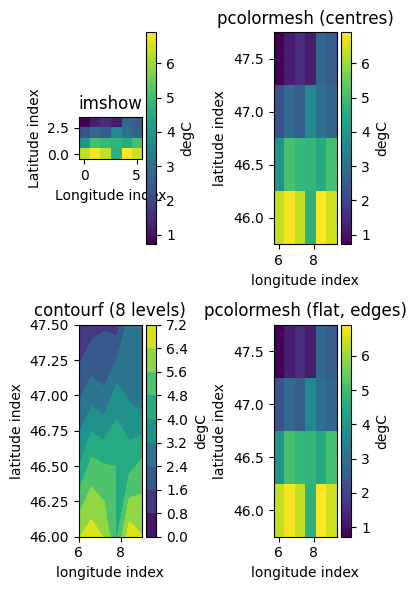

In [13]:
# Your solution here

# =====================================================================
# EXERCICE 10 : un champ, quatre façons (version à trous)
# =====================================================================
#
# OBJECTIF GLOBAL (ce que demande l'énoncé) :
#   Tracer le MÊME petit champ de température quatre fois, dans une figure 2 x 2 :
#     - panneau 1 : imshow (la ligne 0 = latitude la plus au sud,
#                   elle doit apparaître en BAS) ;
#     - panneau 2 : pcolormesh avec lon/lat comme centres de cases ;
#     - panneau 3 : contourf avec 8 niveaux ;
#     - panneau 4 : pcolormesh avec shading="flat" et les BORDS des cases
#                   (un point de plus que de centres, en commençant une demi-maille
#                   avant le premier centre). Il doit être identique au panneau 2.
#   Chaque panneau a une colorbar avec label. Les axes du panneau imshow sont
#   en indices de grille, les trois autres en degrés. La figure est enregistrée
#   dans _files/field.svg.
#
# Schéma général : construire le champ -> créer la grille 2x2 -> tracer 4 fois
#                  -> habiller chaque panneau -> sauvegarder.
# Idée du chapitre : les quatre méthodes ne placent pas les données de la même
#   façon. imshow ne connaît pas les coordonnées (seulement des indices),
#   pcolormesh et contourf les utilisent. D'où le piège de l'imshow à l'envers.
# =====================================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# CELLULE FOURNIE PAR L'ÉNONCÉ (setup partagé, à lancer d'abord)
# Ce que ça fait : crée un générateur aléatoire `rng`, utilisé pour le bruit du champ.
# ---------------------------------------------------------------------
rng = np.random.default_rng(1)

# ---------------------------------------------------------------------
# ÉTAPE 1 : CONSTRUIRE LE CHAMP (fourni par l'énoncé, ne pas modifier)
# Ce que fait cette étape :
#   - lon : 6 longitudes de 6.0 à 9.0 ; lat : 4 latitudes de 46.0 à 47.5 ;
#   - la latitude est CROISSANTE (sud -> nord) : la ligne 0 est la plus au sud ;
#   - field_celsius a la forme (4, 6) = (latitude, longitude),
#     avec une température qui baisse quand on monte vers le nord, plus du bruit.
# ---------------------------------------------------------------------
lon = np.linspace(6.0, 9.0, 6)
lat = np.linspace(46.0, 47.5, 4)      # ascending: south -> north
field_celsius = 6.0 + (46.0 - lat)[:, None] * 3.0 + rng.normal(0, 1.0, size=(4, 6))
print(lon.shape, lat.shape, field_celsius.shape)   # TODO : attendu (6,) (4,) (4, 6)

# ---------------------------------------------------------------------
# ÉTAPE 2 : CRÉER LA FIGURE 2 x 2
# Énoncé : "draw it four times in a 2 x 2 figure".
# Ce que fait cette étape :
#   - plt.subplots(2, 2, ...) renvoie `axes`, un tableau de forme (2, 2) ;
#   - on accède à un panneau par axes[ligne, colonne] :
#     axes[0, 0] = haut gauche, axes[0, 1] = haut droite,
#     axes[1, 0] = bas gauche, axes[1, 1] = bas droite.
# Choisis une taille qui laisse de la place aux colorbars (par exemple 10 x 7).
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(4, 6))   # TODO
print(axes.shape)                                        # TODO : attendu (2, 2)

# ---------------------------------------------------------------------
# ÉTAPE 3 : PANNEAU 1, imshow
# Énoncé : "with imshow (row 0 is the southernmost latitude, so make it appear
#           at the bottom)" ; "label the imshow panel's axes in grid index".
# Ce que fait cette étape :
#   - imshow dessine un tableau comme une image, SANS lire lon/lat ;
#   - par défaut, imshow met la ligne 0 EN HAUT. Ici la ligne 0 est le sud,
#     donc la carte serait à l'envers (nord et sud inversés, sans aucune erreur) ;
#   - le paramètre origin décide de quel côté se place la ligne 0 :
#     "upper" (défaut) ou "lower" ;
#   - les axes montrent donc des indices de colonnes et de lignes, pas des degrés.
# ---------------------------------------------------------------------
im = axes[0, 0].imshow(field_celsius, origin="lower")          # TODO : quel tableau ? quelle valeur de origin ?
axes[0, 0].set_xlabel("Longitude index")                       # TODO : en indices de grille
axes[0, 0].set_ylabel("Latitude index")                       # TODO : idem
axes[0, 0].set_title("imshow")
fig.colorbar(im, ax=axes[0, 0], label="degC")       # TODO : grandeur et unité

# ---------------------------------------------------------------------
# ÉTAPE 4 : PANNEAU 2, pcolormesh avec les coordonnées comme centres
# Énoncé : "with pcolormesh using the coordinates as cell centres".
# Ce que fait cette étape :
#   - pcolormesh(x, y, champ) dessine une case colorée par valeur ;
#   - quand x et y ont la même taille que les colonnes et les lignes du champ
#     (ici 6 et 4), matplotlib les prend comme CENTRES des cases ;
#   - ici les axes sont en degrés, car les coordonnées sont lues.
# ---------------------------------------------------------------------
pcm = axes[0, 1].pcolormesh(lon, lat, field_celsius)       # TODO : x, y, champ (dans cet ordre)
axes[0, 1].set_xlabel("longitude index")                       # TODO : en degrés
axes[0, 1].set_ylabel("latitude index")                       # TODO
axes[0, 1].set_title("pcolormesh (centres)")
fig.colorbar(pcm, ax=axes[0, 1], label="degC")      # TODO

# ---------------------------------------------------------------------
# ÉTAPE 5 : PANNEAU 3, contourf avec 8 niveaux
# Énoncé : "with contourf using 8 levels".
# Ce que fait cette étape :
#   - contourf trace des zones remplies entre des niveaux de valeur,
#     donc des courbes lissées et non des cases ;
#   - le paramètre levels accepte un entier : matplotlib choisit alors lui-même
#     des niveaux "ronds" (environ ce nombre).
# ---------------------------------------------------------------------
cf = axes[1, 0].contourf(lon, lat, field_celsius, levels=8)   # TODO : x, y, champ, nombre de niveaux
axes[1, 0].set_xlabel("longitude index")                            # TODO
axes[1, 0].set_ylabel("latitude index")                            # TODO
axes[1, 0].set_title("contourf (8 levels)")
fig.colorbar(cf, ax=axes[1, 0], label="degC")            # TODO

# ---------------------------------------------------------------------
# ÉTAPE 6 : PANNEAU 4, pcolormesh avec les bords des cases
# Énoncé : "with pcolormesh and shading="flat". The last needs the cell edges:
#           one more value than there are centres along each axis, starting
#           half a grid step before the first centre."
# Ce que fait cette étape :
#   - avec shading="flat", pcolormesh veut les BORDS des cases, pas les centres :
#     N cases ont N+1 bords (6 colonnes -> 7 bords ; 4 lignes -> 5 bords) ;
#   - pour construire les bords, il faut :
#       1) le pas de la grille (écart entre deux centres successifs),
#       2) le premier bord = premier centre - pas / 2,
#       3) le dernier bord = dernier centre + pas / 2,
#       4) N + 1 valeurs régulièrement espacées entre les deux (np.linspace).
#   - le résultat doit être identique au panneau 2.
# ---------------------------------------------------------------------
dlon = lon[1] - lon[0]                                       # TODO : pas en longitude (par exemple lon[1] - lon[0])
dlat = lat[1] - lat[0]                                      # TODO : pas en latitude
lon_edges = np.linspace(lon[0] - dlon / 2, lon[-1] + dlon / 2, len(lon) + 1)
lat_edges = np.linspace(lat[0] - dlat / 2, lat[-1] + dlat / 2, len(lat) + 1)
print(lon_edges.shape, lat_edges.shape)    # doit afficher (7,) (5,)         # TODO : attendu (7,) (5,)

pcm_flat = axes[1, 1].pcolormesh(lon_edges, lat_edges, field_celsius, shading="flat")   # TODO : bords x, bords y, champ
axes[1, 1].set_xlabel("longitude index")                                        # TODO
axes[1, 1].set_ylabel("latitude index")                                        # TODO
axes[1, 1].set_title("pcolormesh (flat, edges)")
fig.colorbar(pcm_flat, ax=axes[1, 1], label="degC")                  # TODO

# ---------------------------------------------------------------------
# ÉTAPE 7 : FINITIONS ET SAUVEGARDE
# Énoncé : "save the figure as _files/field.svg".
# Ce que fait cette étape :
#   - tight_layout ajuste les marges ;
#   - os.makedirs crée le dossier _files s'il n'existe pas (sinon savefig échoue) ;
#   - savefig écrit le fichier ; l'extension .svg choisit le format vectoriel ;
#   - on sauvegarde AVANT plt.show(), qui peut vider la figure dans certains
#     environnements.
# ---------------------------------------------------------------------
plt.tight_layout()                                        # TODO : ajuster les marges
os.makedirs("_files", exist_ok=True)
fig.savefig("_files/field.svg")                      # TODO : quelle méthode de sauvegarde ?
plt.show()

# ---------------------------------------------------------------------
# AUTO-VÉRIFICATION (pas de commentaire demandé ici, mais regarde bien)
# Compare les panneaux :
#   - les panneaux 2 et 4 sont-ils identiques ? (ils doivent l'être)
#   - le panneau 1 a-t-il le nord en haut ? (si les valeurs les plus froides
#     ne sont pas en haut, vérifie origin)
#   - contourf paraît-il plus lisse que les deux pcolormesh ? Pourquoi ?
# ---------------------------------------------------------------------

## Exercise 11: A vector field

Build the synthetic wind field below — a simple rotation, like a cyclone seen from above — and
draw it two ways in a 1 × 2 figure. On the left, `quiver` at every third grid point, over
`contour` lines of the wind speed. On the right, `streamplot` coloured by wind speed, with a
labelled colorbar whose unit, metres per second, is written with mathtext (1.4.5) so the
exponent is a real superscript. Label the axes in km.

```python
x_km = np.linspace(-100, 100, 25)
y_km = np.linspace(-100, 100, 25)
xx_km, yy_km = np.meshgrid(x_km, y_km)
u_ms = -yy_km / 8.0
v_ms = xx_km / 8.0
```

In [ ]:
# Your solution here

## Exercise 12: Fix the map

The cell below draws a temperature anomaly field — the departure from a long-term mean, in °C, on
a 0.5° grid over the Alps — and breaks most of the checklist in 1.4.12. First list every practice
it breaks, as comments. Then redraw the same data so that it passes all of them.

In [ ]:
# Pre-supplied: a map that breaks most of the checklist.
# Leave this cell as it is -- write the corrected version in the next one.
anomaly_lon = np.linspace(5.0, 11.0, 13)
anomaly_lat = np.linspace(45.0, 48.0, 7)                     # ascending: south -> north
anomaly_celsius = ((46.5 - anomaly_lat)[:, None] * 1.5
                   + 0.4 * np.sin(anomaly_lon)[None, :]
                   + rng.normal(0, 0.3, size=(7, 13)))

fig, ax = plt.subplots(figsize=(3, 2))
ax.imshow(anomaly_celsius, cmap="jet")
ax.set_title("anomaly")
plt.show()

In [ ]:
# Your solution here

## Exercise 13: Build a labelled DataArray

From `data = np.arange(12.0).reshape(3, 4)`, build an xarray DataArray with dimensions
`("lat", "lon")`, latitude coordinates `[46.0, 46.5, 47.0]`, longitude coordinates
`[6.0, 6.5, 7.0, 7.5]`, and a `units` attribute of `"degC"`. Print its dims and its units.

In [ ]:
import numpy as np
import xarray as xr

# Données fournies par l'énoncé
data = np.arange(12.0).reshape(3, 4)
lats = [46.0, 46.5, 47.0]
lons = [6.0, 6.5, 7.0, 7.5]

# Construction du DataArray labélisé
da = xr.DataArray(
    data,
    dims=("lat", "lon"),
    coords={"lat": lats, "lon": lons},
    attrs={"units": "degC"}
)

# Affichage des dimensions et des unités
print("Dimensions :", da.dims)
print("Unités :", da.attrs["units"])
print("\nStructure du DataArray :")
display(da)

Dimensions : ('lat', 'lon')
Unités : degC

Structure du DataArray :


<xarray.DataArray (lat: 3, lon: 4)> Size: 96B
array([[ 0.,  1.,  2.,  3.],
       [ 4.,  5.,  6.,  7.],
       [ 8.,  9., 10., 11.]])
Coordinates:
  * lat      (lat) float64 24B 46.0 46.5 47.0
  * lon      (lon) float64 32B 6.0 6.5 7.0 7.5
Attributes:
    units:    degC

## Exercise 14: Select, reduce, and subtract

Build the small Dataset below, then:

1. Print the spatial mean of the first day (by position) and the time mean at each longitude
   along 47.0° N (by label).
2. Select the grid point nearest 46.8° N, 6.3° E, and print its coordinates and its ten values.
3. Subtract each day's spatial mean — the mean over `lat` and `lon` — from the field. Print the
   dims of the result, and its spatial mean on the first day, which should be zero up to rounding.

```python
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2024-01-11", dtype="datetime64[D]")
lat = np.array([46.0, 46.5, 47.0]); lon = np.array([6.0, 6.5, 7.0, 7.5])
t = rng.normal(5, 3, size=(10, 3, 4))
ds = xr.Dataset({"t2m": (("time", "lat", "lon"), t)},
                coords={"time": time, "lat": lat, "lon": lon})
```

In [22]:
# Your solution here

# =====================================================================
# EXERCICE 14 : sélectionner, réduire et soustraire (version à trous)
# =====================================================================
#
# OBJECTIF GLOBAL (ce que demande l'énoncé) :
#   À partir d'un petit Dataset xarray (température sur 10 jours, 3 latitudes,
#   4 longitudes), faire trois choses :
#     1. afficher deux moyennes :
#          - la moyenne spatiale du PREMIER jour (choisi par POSITION),
#          - la moyenne dans le temps pour chaque longitude, le long de 47.0 °N
#            (choisi par ÉTIQUETTE) ;
#     2. sélectionner le point de grille le plus proche de 46.8 °N, 6.3 °E,
#        puis afficher ses coordonnées et ses dix valeurs ;
#     3. retirer à chaque jour sa moyenne spatiale (calculée sur lat ET lon),
#        puis afficher les dimensions du résultat et sa moyenne spatiale du
#        premier jour, qui doit valoir zéro à l'arrondi près.
#
# Idées du chapitre :
#   - .isel choisit par POSITION (0, 1, 2...), .sel choisit par ÉTIQUETTE (47.0, ...) ;
#   - une réduction (mean) se fait sur une dimension NOMMÉE, jamais sur un numéro d'axe ;
#   - xarray aligne les opérations sur les noms de dimensions (pas besoin de np.newaxis).
# =====================================================================

import numpy as np
import xarray as xr

# ---------------------------------------------------------------------
# CELLULE FOURNIE PAR L'ÉNONCÉ (ne pas modifier)
# Ce que ça fait :
#   - crée un Dataset `ds` avec une variable "t2m" de forme (10, 3, 4),
#     dont les dimensions sont ("time", "lat", "lon") ;
#   - time = 10 jours (1er au 10 janvier 2024) ; lat = 46.0, 46.5, 47.0 ;
#     lon = 6.0, 6.5, 7.0, 7.5 ; les valeurs sont aléatoires (moyenne 5, écart 3).
# ---------------------------------------------------------------------
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2024-01-11", dtype="datetime64[D]")
lat = np.array([46.0, 46.5, 47.0]); lon = np.array([6.0, 6.5, 7.0, 7.5])
t = rng.normal(5, 3, size=(10, 3, 4))
ds = xr.Dataset({"t2m": (("time", "lat", "lon"), t)},
                coords={"time": time, "lat": lat, "lon": lon})
print(ds)    # TODO : repère les dimensions, les coordonnées et le nom de la variable

# ---------------------------------------------------------------------
# PARTIE 1a : MOYENNE SPATIALE DU PREMIER JOUR (sélection par POSITION)
# Énoncé : "Print the spatial mean of the first day (by position)".
# Ce que fait cette étape :
#   - .isel(time=0) garde le premier jour, c'est-à-dire la position 0 sur la
#     dimension "time" (on ne regarde pas la date, seulement la position) ;
#   - il reste alors un tableau 2D (lat, lon) ;
#   - la moyenne spatiale est la moyenne sur les DEUX dimensions lat et lon :
#     .mean(dim=...) accepte un tuple de noms pour réduire plusieurs dimensions à la fois.
# Résultat : un seul nombre (un tableau de dimension 0).
# ---------------------------------------------------------------------
first_day = ds["t2m"].isel(time=0)                 # TODO : quelle méthode (par position) ? quelle valeur ?
spatial_mean_day0 = first_day.mean(dim=("lat", "lon"))  # TODO : les deux dimensions spatiales, entre guillemets
print(spatial_mean_day0.values)                     # .values pour n'afficher que le nombre

# ---------------------------------------------------------------------
# PARTIE 1b : MOYENNE DANS LE TEMPS LE LONG DE 47.0 °N (sélection par ÉTIQUETTE)
# Énoncé : "the time mean at each longitude along 47.0 N (by label)".
# Ce que fait cette étape :
#   - .sel(lat=47.0) garde la latitude dont l'ÉTIQUETTE est 47.0 (pas la position) :
#     on choisit par valeur de coordonnée, comme dans un dictionnaire ;
#   - il reste un tableau 2D (time, lon) ;
#   - la moyenne sur "time" fait disparaître le temps : il reste une valeur par longitude.
# Résultat attendu : un tableau de forme (4,), une moyenne par longitude.
# ---------------------------------------------------------------------
band = ds["t2m"].sel(lat=47.0)                       # TODO : quelle méthode (par étiquette) ? quelle valeur ?
time_mean_47 = band.mean(dim="time")                   # TODO : quelle dimension doit disparaître ?
print(time_mean_47.values)                          # TODO : attendu : 4 valeurs
print(time_mean_47.shape)                           # TODO : attendu (4,)

# ---------------------------------------------------------------------
# PARTIE 2 : LE POINT DE GRILLE LE PLUS PROCHE
# Énoncé : "Select the grid point nearest 46.8 N, 6.3 E, print its coordinates
#           and its ten values."
# Ce que fait cette étape :
#   - 46.8 et 6.3 ne sont PAS sur la grille (lat = 46.0, 46.5, 47.0 ;
#     lon = 6.0, 6.5, 7.0, 7.5). Un .sel exact lèverait une erreur (KeyError) ;
#   - avec method="nearest", xarray choisit pour chaque dimension l'étiquette
#     la plus proche de la valeur demandée ;
#   - il reste une série de 10 valeurs (une par jour) pour ce point de grille.
# ---------------------------------------------------------------------
point = ds["t2m"].sel(lat=46.8, lon=6.3, method="nearest")   # TODO : valeurs demandées, et méthode "nearest"
print(point["lat"].values, point["lon"].values)       # TODO : attendu : 47.0 et 6.5 (les plus proches)
print(point.values)                                   # TODO : attendu : 10 valeurs
print(point.shape)                                    # TODO : attendu (10,)

# ---------------------------------------------------------------------
# PARTIE 3 : SOUSTRAIRE LA MOYENNE SPATIALE DE CHAQUE JOUR
# Énoncé : "Subtract each day's spatial mean -- the mean over lat and lon --
#           from the field. Print the dims of the result, and its spatial mean
#           on the first day, which should be zero up to rounding."
# Ce que fait cette étape :
#   - la moyenne sur (lat, lon) donne UNE valeur par jour : dimensions ("time",) ;
#   - xarray soustrait en alignant les NOMS de dimensions : la moyenne de chaque
#     jour est retirée de toutes les cases de ce jour, sans boucle ni
#     remodelage manuel (contrairement à numpy, vu au chapitre 1.3) ;
#   - le résultat garde les trois dimensions d'origine ;
#   - après soustraction, la moyenne spatiale de chaque jour vaut 0 (aux erreurs
#     d'arrondi près, de l'ordre de 1e-16).
# ---------------------------------------------------------------------
daily_spatial_mean = ds["t2m"].mean(dim=("lat", "lon"))   # TODO : quelles dimensions ?
print(daily_spatial_mean.dims, daily_spatial_mean.shape)   # TODO : attendu ('time',) (10,)

anomaly = ds["t2m"] - daily_spatial_mean            # TODO : quelle opération ?
print(anomaly.dims)                                   # TODO : attendu ('time', 'lat', 'lon')

check = anomaly.isel(time=0).mean(dim=("lat", "lon"))
print(check.values)                                   # TODO : attendu : un nombre proche de 0 (par exemple 1e-16)

# ---------------------------------------------------------------------
# AUTO-VÉRIFICATION
# Résume ce que tu viens de pratiquer :
#   - .isel(time=0) contre .sel(lat=47.0) : par position ou par étiquette ?
#   - mean(dim=...) : la dimension citée disparaît, les autres restent ;
#   - method="nearest" : à utiliser quand la valeur demandée n'est pas sur la grille ;
#   - soustraction par noms de dimensions : pas de remodelage nécessaire.
# ---------------------------------------------------------------------

('time',) (10,)
('time', 'lat', 'lon')
-1.4802973661668753e-16


## Exercise 15: Monthly anomalies, two ways

Build the one-year daily temperature DataArray below and subtract its annual mean to get each
day's anomaly. Compute the monthly mean anomaly with `resample`, and print the calendar month
(1–12) whose mean anomaly is largest. Then compute the monthly mean anomaly again with
`groupby("time.month")`, and print the largest difference between the two sets of twelve values.
In a comment, say why the two agree here, and what would differ between them for a ten-year
record.

```python
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2025-01-01", dtype="datetime64[D]")
n = time.size; doy = np.arange(n)
t = 5 + -np.cos(2 * np.pi * doy / n) * 10 + rng.normal(0, 1.5, n)
da = xr.DataArray(t, dims="time", coords={"time": time}, attrs={"units": "degC"})
```

In [ ]:
# Your solution here

## Exercise 16: Round-trip through netCDF

Build a Dataset holding one 1D temperature variable, `t2m`, with a `units` attribute. Write it to
`_files/series.nc`, reopen it with `open_dataset`, and print the variable names and the recovered
units.

In [ ]:
# Your solution here

## Exercise 17: What transform does

Rebuild the DataArray `da` from exercise 13 and draw it twice, side by side, on
`ccrs.EqualEarth()` maps cropped with `set_extent([5, 9, 45, 48], crs=ccrs.PlateCarree())` and
with `cfeature.BORDERS` added: once with `pcolormesh(..., transform=ccrs.PlateCarree())`, and
once with `transform` left out. Give the first panel a labelled colorbar. In a comment, say where
the field in the second panel went, and why no error was raised.

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


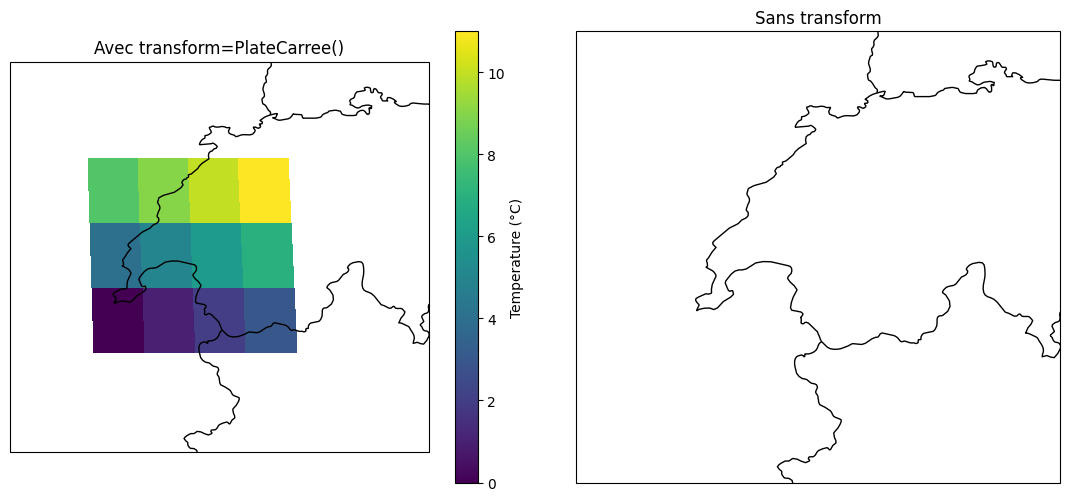

In [ ]:
# =====================================================================
# EXERCICE 17 : À quoi sert l'argument transform ? (version résolue)
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---------------------------------------------------------------------
# ÉTAPE 1 : RECONSTRUIRE LE DATAARRAY DE L'EXERCICE 13
# ---------------------------------------------------------------------
data = np.arange(12.0).reshape(3, 4)
lats = [46.0, 46.5, 47.0]
lons = [6.0, 6.5, 7.0, 7.5]

da = xr.DataArray(
    data,
    dims=("lat", "lon"),
    coords={"lat": lats, "lon": lons},
    attrs={"units": "degC"}
)

# ---------------------------------------------------------------------
# ÉTAPE 2 : INITIALISER LA FIGURE ET LES PROJECTIONS
# On configure les cartes avec la projection cible demandée : EqualEarth
# ---------------------------------------------------------------------
projection_cible = ccrs.EqualEarth()

fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 5),
    subplot_kw={"projection": projection_cible}
)

# ---------------------------------------------------------------------
# ÉTAPE 3 : CONFIGURATION COMMUNE DES DEUX CARTES
# ---------------------------------------------------------------------
for ax in axes:
    # Les limites géographiques de set_extent sont en PlateCarree (lon/lat classiques)
    ax.set_extent([5, 9, 45, 48], crs=ccrs.PlateCarree())

    # Ajout des frontières et des côtes pour donner du contexte
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=1)
    ax.coastlines()

# ---------------------------------------------------------------------
# ÉTAPE 4 : TRACÉ SUR LE PANNEAU GAUCHE (AVEC TRANSFORM)
# ---------------------------------------------------------------------
ax_left = axes[0]

pcm = da.plot.pcolormesh(
    ax=ax_left,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)
fig.colorbar(pcm, ax=ax_left, label="Temperature (°C)")
ax_left.set_title("Avec transform=PlateCarree()")

# ---------------------------------------------------------------------
# ÉTAPE 5 : TRACÉ SUR LE PANNEAU DROIT (SANS TRANSFORM)
# ---------------------------------------------------------------------
ax_right = axes[1]

da.plot.pcolormesh(
    ax=ax_right,
    x="lon",
    y="lat",
    add_colorbar=False
)
ax_right.set_title("Sans transform")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# ÉTAPE 6 : LE COMMENTAIRE EXPLICATIF
# ---------------------------------------------------------------------
# Sans l'argument `transform`, Cartopy suppose que les coordonnées fournies (lons, lats)
# sont déjà exprimées dans la projection de l'affichage (ici, EqualEarth en mètres).
# Les coordonnées (entre 5 et 48) sont donc interprétées à quelques mètres seulement
# du centre d'origine (0, 0) de la carte, loin en mer au large de l'Afrique.
# Le panneau de droite s'étant recadré sur les Alpes (en Europe), le dessin de quelques mètres
# se retrouve complètement en dehors de la région affichée, d'où sa disparition sans générer d'erreur.

In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 20.2 MB/s eta 0:00:00


## Exercise 18: Choosing a projection

Each figure described below needs a map. For each, choose a projection from 1.4.13 and draw the
empty map — land, ocean, and coastline, cropped with `set_extent` where the figure covers less
than the globe. Draw the three as panels of one figure; each panel needs its own projection, so
create each axes with `fig.add_subplot`. Justify each choice in a comment of one or two sentences.

1. The extent of Arctic sea ice in September. `ccrs.NorthPolarStereo()` is the northern
   counterpart of `SouthPolarStereo`.
2. How much of each continent is covered by tropical forest, for a reader who will compare the
   areas by eye.
3. A warm anomaly spreading through the Southern Ocean into the Atlantic, Indian, and Pacific
   basins, for a figure whose point is that the Southern Ocean links all three.

In [ ]:
# Your solution here

## Exercise 19: NASA's real global-temperature record

The file cached below is NASA GISS's monthly global-mean surface temperature anomaly (°C,
relative to a 1951–1980 baseline), one row per year since 1880, one column per calendar month.
A handful of recent months are still missing, marked `***`.

Wrap the twelve month columns in an xarray `DataArray` with dims `("year", "month")` and a `units`
attribute, then draw two figures: the annual mean as a line against year, and the full
`(year, month)` array with xarray's own `.plot()`. In a comment, compare what the warming trend
looks like read month by month against the single annual line.

In [ ]:
# Pre-supplied: download the data file and cache it locally.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/nasa_gistemp_global_temp_anomaly.csv",
    known_hash="sha256:6cfa44e7bbacd9b12cb10bdd64b3182c2735fa3f3a95688e1f7bc8e5dfcece93",
    fname="nasa_gistemp_global_temp_anomaly.csv",
    path=pooch.os_cache("mlees"),
)

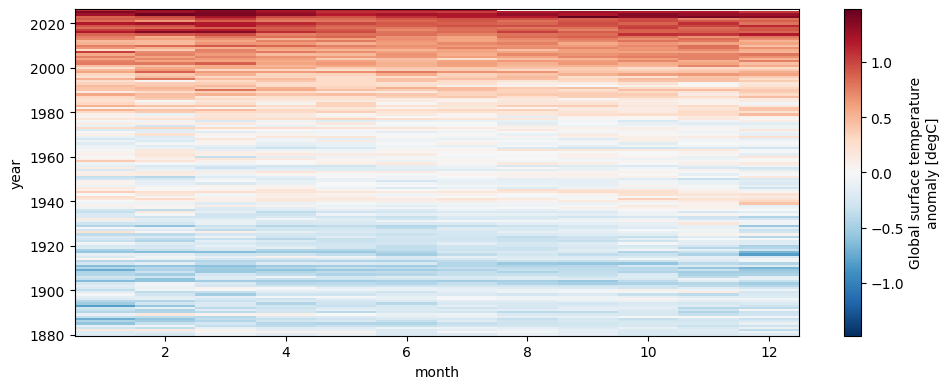

In [ ]:
# Your solution here

# =====================================================================
# EXERCICE 19 : température globale NASA (version à trous)
# =====================================================================
#
# OBJECTIF GLOBAL (ce que demande l'énoncé) :
#   À partir d'un fichier CSV de la NASA (anomalie de température globale,
#   une ligne par année depuis 1880, une colonne par mois) :
#     (a) ranger les 12 colonnes de mois dans un DataArray xarray
#         avec les dimensions ("year", "month") et un attribut "units" ;
#     (b) dessiner 2 figures :
#           - Figure 1 : la moyenne annuelle en ligne, contre l'année ;
#           - Figure 2 : le tableau (année, mois) complet avec .plot() d'xarray ;
#     (c) écrire un commentaire qui compare la tendance vue mois par mois
#         (figure 2) et la tendance vue avec une seule ligne annuelle (figure 1).
#
# Schéma général : charger -> mettre en forme -> réduire -> tracer.
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pooch

# ---------------------------------------------------------------------
# CELLULE FOURNIE PAR L'ÉNONCÉ (ne pas modifier)
# Ce que ça fait : télécharge le fichier CSV et le garde en cache local.
# `path` contient ensuite le chemin du fichier sur ta machine.
# ---------------------------------------------------------------------
path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/nasa_gistemp_global_temp_anomaly.csv",
    known_hash="sha256:6cfa44e7bbacd9b12cb10bdd64b3182c2735fa3f3a95688e1f7bc8e5dfcece93",
    fname="nasa_gistemp_global_temp_anomaly.csv",
    path=pooch.os_cache("mlees"),
)

# ---------------------------------------------------------------------
# ÉTAPE 1 : CHARGER LE FICHIER
# Énoncé : "A handful of recent months are still missing, marked ***."
# Hint de l'énoncé : np.genfromtxt(path, skip_header=1, delimiter=",",
#                    names=True, missing_values="***", filling_values=np.nan)
# Ce que fait cette étape :
#   - skip_header : saute la ligne de titre du fichier (non numérique) ;
#   - delimiter   : indique que les colonnes sont séparées par des virgules ;
#   - names=True  : lit la ligne d'en-tête pour nommer les colonnes
#                   (data["Year"], data["Jan"], ...) ;
#   - missing_values + filling_values : remplace les "***" par NaN,
#                   sinon numpy ne sait pas les lire comme des nombres.
# Résultat : `data`, un tableau à colonnes nommées.
# ---------------------------------------------------------------------
data = np.genfromtxt(path, skip_header=1, delimiter=",", names=True, missing_values="***", filling_values=np.nan)
print(data.dtype.names)   # TODO : regarde les noms des colonnes, tu en as besoin ensuite

# ---------------------------------------------------------------------
# ÉTAPE 2 : EMPILER LES 12 COLONNES DE MOIS EN UN TABLEAU (année, mois)
# Énoncé : "Wrap the twelve month columns in an xarray DataArray with dims
#           ("year", "month")".
# Hint de l'énoncé : np.column_stack((data["Jan"], data["Feb"], ..., data["Dec"]))
# Ce que fait cette étape :
#   - un DataArray a besoin d'UN tableau 2D, pas de 12 colonnes séparées ;
#   - column_stack met les colonnes côte à côte :
#     chaque ligne = une année, chaque colonne = un mois.
# Résultat attendu : `values.shape` = (nombre d'années, 12).
# ---------------------------------------------------------------------
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec" ]                # TODO : compléter les 12 mois
values = np.column_stack([data[m] for m in month_names])    # TODO : que vaut data[...] pour chaque mois ?
print(values.shape)                                     # TODO : vérifie que la forme est (n_années, 12)

# ---------------------------------------------------------------------
# ÉTAPE 3 : CRÉER LE DATAARRAY
# Énoncé : "with dims ("year", "month") and a units attribute".
# Hints de l'énoncé : les coordonnées sont data["Year"] et np.arange(1, 13).
# Ce que fait cette étape :
#   - attache aux nombres des noms de dimensions et des coordonnées
#     (années 1880... et mois 1 à 12) ;
#   - stocke l'unité (°C) dans les attributs ;
#   - `long_name` et `units` serviront à .plot() pour étiqueter
#     automatiquement la colorbar à l'étape 5.
# L'ordre des `dims` doit suivre celui des axes de `values`
# (axe 0 = années, axe 1 = mois).
# ---------------------------------------------------------------------
anomaly = xr.DataArray(values,                                   # le tableau 2D de l'étape 2
    dims=("year", "month"),                       # TODO : noms des deux dimensions, dans le bon ordre
    coords={ "year": data["Year"],             # TODO : nom de la dimension des années
            "month": np.arange(1, 13)},                     # TODO : nom de la dimension des mois, puis valeurs 1 à 12
    attrs={"units": "degC" ,                   # TODO : l'unité de l'anomalie
           "long_name": "Global surface temperature anomaly"},              # TODO : un nom lisible de la grandeur
)
print(anomaly)                             # pour vérifier dims, coords et attrs

# ---------------------------------------------------------------------
# ÉTAPE 4 : FIGURE 1, MOYENNE ANNUELLE EN LIGNE
# Énoncé : "the annual mean as a line against year".
# Hint de l'énoncé : .mean(dim="month") ignore tout seul les mois manquants (NaN).
# Ce que fait cette étape :
#   - on réduit le tableau 2D (année, mois) à une série 1D (année) :
#     une moyenne par année, calculée sur la dimension "month" ;
#   - puis on la trace comme une courbe classique matplotlib.
# Résultat : une courbe de l'anomalie annuelle, depuis 1880.
# ---------------------------------------------------------------------
annual_mean = anomaly.mean(dim="month")         # TODO : quelle méthode ? sur quelle dimension ?

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(data["Year"], annual_mean)                           # TODO : x = les années, y = la moyenne annuelle
ax.set_xlabel("years")                         # TODO
ax.set_ylabel("Global surface temperature anomaly (°C)")                         # TODO : n'oublie pas l'unité
ax.set_title("Global surface temperature anomaly mean per months for each years")                          # TODO
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# ÉTAPE 5 : FIGURE 2, LE TABLEAU COMPLET AVEC .plot() D'XARRAY
# Énoncé : "the full (year, month) array with xarray's own .plot()".
# Hint de l'énoncé : .plot() sur un DataArray 2D dessine un pcolormesh
#                    et étiquette la colorbar avec long_name et units.
# Ce que fait cette étape :
#   - une seule méthode, sans pcolormesh à écrire à la main ;
#   - xarray lit les coordonnées pour les axes (années, mois)
#     et les attributs pour la colorbar ;
#   - si la colorbar est mal étiquetée, le problème vient de l'étape 3.
# Résultat : une carte de couleurs année x mois.
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
anomaly.plot(ax=ax)                         # TODO : la méthode de tracé d'xarray
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# ÉTAPE 6 : LE COMMENTAIRE DEMANDÉ
# Énoncé : "In a comment, compare what the warming trend looks like read month
#           by month against the single annual line."
# Ce que fait cette étape : tu interprètes les deux figures ; il n'y a pas de code.
# Pistes pour ta réponse (à reformuler avec tes mots) :
#   - la figure 2 montre-t-elle la même tendance pour tous les mois ?
#     Y a-t-il des différences entre mois ?
#   - que perd-on quand on fait la moyenne sur les 12 mois ?
#   - que gagne-t-on, en lisibilité, avec la ligne unique de la figure 1 ?
# TODO : écris ici 2-3 phrases.
# ---------------------------------------------------------------------

# Hint: load the file with
#       np.genfromtxt(path, skip_header=1, delimiter=",", names=True,
#                     missing_values="***", filling_values=np.nan)
#       -- names=True reads the header row, so the columns are data["Year"], data["Jan"], ...
# Hint: np.column_stack((data["Jan"], data["Feb"], ..., data["Dec"])) puts the twelve month
#       columns side by side as one (year, month) array
# Hint: the coordinates are data["Year"] and np.arange(1, 13)
# Hint: .mean(dim="month") skips the missing months on its own
# Hint: .plot() on the 2D DataArray draws a pcolormesh, and labels the colorbar from the
#       long_name and units attributes

## Replicating plots

The four exercises below each show a figure built from a real dataset and ask you to rebuild it
as closely as you can. The data arrive through a pre-supplied `pooch` cell; everything after that
is yours.

Work towards the target one element at a time — get the data onto the axes first, then the
coordinates, then the colours, then the labels — rather than trying to write the whole cell in
one go.

## Exercise 20: Global surface air temperature and its zonal mean

The three files cached below hold one snapshot of surface air temperature from the
[NCEP/NCAR atmospheric reanalysis 1](https://psl.noaa.gov/data/gridded/data.ncep.reanalysis.html),
as plain numpy arrays: `lon` (192 longitudes), `lat` (94 latitudes, running north to south), and
`temp_kelvin`, the field itself with shape `(94, 192)` — **in kelvin**.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-global-temperature.png" alt="A filled contour map of global surface air temperature in magma colours with a white dashed contour at minus ten degrees, beside a line plot of the zonal mean against latitude" width="100%">

<em>The figure to replicate. Left: the field as filled contours, with a single white contour drawn
at −10 °C. Right: the zonal mean — the average along longitude — against latitude.</em>


Rebuild it, and say in a comment which hemisphere's winter this snapshot was taken in, and how
the zonal mean tells you.

In [ ]:
# Pre-supplied: download the three arrays and cache them locally.
import pooch

In [ ]:
base_url = "https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/"

In [ ]:
path_lon = pooch.retrieve(
    url=base_url + "ncep_global_temp_lon.npy",
    known_hash="sha256:eaf54b88dd89279d3034da17fe8470dc2c841bf9fa89b2aa741dacff9c326cdb",
    fname="ncep_global_temp_lon.npy",
    path=pooch.os_cache("mlees"),
)
path_lat = pooch.retrieve(
    url=base_url + "ncep_global_temp_lat.npy",
    known_hash="sha256:af1f438080460e1fca4583b2ec19b44285a3d3776e4d21b8da9b6e162906c88a",
    fname="ncep_global_temp_lat.npy",
    path=pooch.os_cache("mlees"),
)
path_temp = pooch.retrieve(
    url=base_url + "ncep_global_temp_kelvin.npy",
    known_hash="sha256:e040ca257334708b43e86398e09a5669fcf051179ecf5dcd278f758d67beed20",
    fname="ncep_global_temp_kelvin.npy",
    path=pooch.os_cache("mlees"),
)

(192,) (94,) (94, 192)
-53.61 35.580017
(94,)


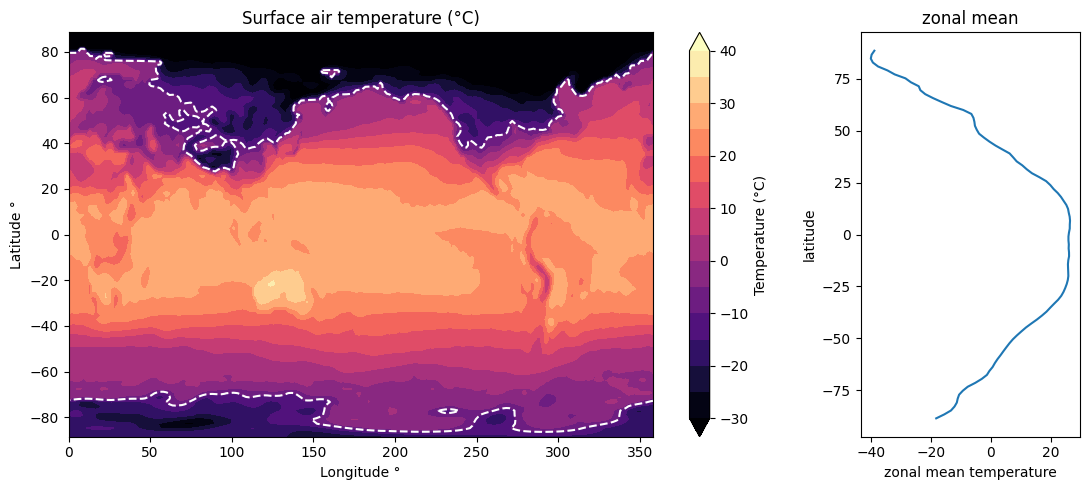

In [ ]:
# Your solution here

# =====================================================================
# EXERCICE 20 : température de l'air en surface et moyenne zonale (à trous)
# =====================================================================
#
# OBJECTIF GLOBAL (ce que demande l'énoncé) :
#   À partir d'un instantané de la réanalyse NCEP/NCAR (trois tableaux numpy :
#   lon, lat, temp_kelvin), reproduire une figure à deux panneaux :
#     - Panneau de gauche : le champ de température global en contours remplis
#       (palette "magma"), avec une seule ligne de contour blanche à -10 °C ;
#     - Panneau de droite : la moyenne zonale (moyenne le long de la longitude)
#       tracée contre la latitude ;
#   puis écrire un commentaire : de quel hémisphère est-ce l'hiver sur cet
#   instantané, et comment la moyenne zonale le montre-t-elle ?
#
# Schéma général : charger -> convertir -> créer la figure -> tracer le champ
#                  -> tracer la moyenne zonale -> habiller.
# Rappel : la température est en KELVIN dans le fichier, la figure est en °C.
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
import pooch

# ---------------------------------------------------------------------
# CELLULE FOURNIE PAR L'ÉNONCÉ (ne pas modifier)
# Ce que ça fait : télécharge les trois fichiers .npy et les garde en cache.
# Tu obtiens trois chemins : path_lon, path_lat, path_temp.
# ---------------------------------------------------------------------
base_url = "https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/"

path_lon = pooch.retrieve(
    url=base_url + "ncep_global_temp_lon.npy",
    known_hash="sha256:eaf54b88dd89279d3034da17fe8470dc2c841bf9fa89b2aa741dacff9c326cdb",
    fname="ncep_global_temp_lon.npy",
    path=pooch.os_cache("mlees"),
)
path_lat = pooch.retrieve(
    url=base_url + "ncep_global_temp_lat.npy",
    known_hash="sha256:af1f438080460e1fca4583b2ec19b44285a3d3776e4d21b8da9b6e162906c88a",
    fname="ncep_global_temp_lat.npy",
    path=pooch.os_cache("mlees"),
)
path_temp = pooch.retrieve(
    url=base_url + "ncep_global_temp_kelvin.npy",
    known_hash="sha256:e040ca257334708b43e86398e09a5669fcf051179ecf5dcd278f758d67beed20",
    fname="ncep_global_temp_kelvin.npy",
    path=pooch.os_cache("mlees"),
)

# ---------------------------------------------------------------------
# ÉTAPE 1 : CHARGER LES TROIS TABLEAUX
# Énoncé : "lon (192 longitudes), lat (94 latitudes, running north to south),
#           and temp_kelvin, the field itself with shape (94, 192) -- in kelvin."
# Hint de l'énoncé : np.load chaque fichier.
# Ce que fait cette étape :
#   - np.load lit un fichier .npy et renvoie le tableau numpy qu'il contient ;
#   - on obtient les coordonnées (lon, lat) et le champ de température.
# ---------------------------------------------------------------------
lon = np.load(path_lon)              # TODO : quelle fonction ? quel chemin ?
lat = np.load(path_lat)              # TODO
temp_kelvin = np.load(path_temp)      # TODO
print(lon.shape, lat.shape, temp_kelvin.shape)   # TODO : attendu (192,) (94,) (94, 192)

# ---------------------------------------------------------------------
# ÉTAPE 2 : CONVERTIR LES KELVINS EN DEGRÉS CELSIUS
# Énoncé : "temp_kelvin ... in kelvin" alors que la figure est en °C
#          (le contour est à -10 °C, la colorbar va de -30 à 40).
# Hint de l'énoncé : subtract 273.15 to go from kelvin to degrees celsius.
# Ce que fait cette étape : une soustraction appliquée à tout le tableau d'un coup
#   (pas de boucle : c'est le principe de numpy vu au chapitre 1.3).
# ---------------------------------------------------------------------
temp_celsius = temp_kelvin - 273.15            # TODO : quelle opération, quelle valeur ?
print(temp_celsius.min(), temp_celsius.max()) # TODO : les valeurs te semblent-elles réalistes en °C ?

# ---------------------------------------------------------------------
# ÉTAPE 3 : CRÉER LA FIGURE À DEUX PANNEAUX DE LARGEURS DIFFÉRENTES
# Énoncé : "a filled contour map ... beside a line plot of the zonal mean".
# Hint de l'énoncé : plt.subplots(1, 2, figsize=(11, 5),
#                    gridspec_kw={"width_ratios": [5, 1.5]})
# Ce que fait cette étape :
#   - 1 ligne, 2 colonnes : deux axes côte à côte, rangés dans le tableau `axes` ;
#   - width_ratios rend le panneau de gauche environ 3 fois plus large
#     que celui de droite (5 contre 1.5).
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 5),
                         gridspec_kw={"width_ratios": [5, 1.5]})   # TODO : valeurs de l'énoncé

# ---------------------------------------------------------------------
# ÉTAPE 4 : PANNEAU DE GAUCHE, LE CHAMP EN CONTOURS REMPLIS
# Énoncé : "the field as filled contours, with a single white contour at -10 C".
# Hints de l'énoncé :
#   - contourf avec cmap="magma", levels=np.linspace(-30, 40, 15), extend="both" ;
#   - contour avec levels=[-10] et colors="w" par-dessus ;
#   - matplotlib met en pointillés un contour de niveau négatif, tout seul.
# Ce que fait cette étape :
#   - contourf(lon, lat, champ) colore les zones entre deux niveaux ;
#   - levels fixe les 15 niveaux de -30 à 40 ;
#   - extend="both" colore aussi les valeurs hors de -30..40
#     (flèches aux deux bouts de la colorbar) ;
#   - contour dessine une seule ligne blanche, par-dessus, à -10 °C ;
#   - la colorbar traduit les couleurs en °C : elle doit porter son label.
# ---------------------------------------------------------------------
ax_map = axes[0]                                      # TODO : quel indice pour le panneau de gauche ?

cf = ax_map.contourf(lon, lat, temp_celsius,                     # TODO : x, y, champ (dans cet ordre)
                     cmap="magma", levels=np.linspace(-30, 40, 15), extend="both")
ax_map.contour(lon, lat, temp_celsius, levels=[-10], colors="w") # TODO : mêmes x, y, champ ; niveau -10 ; couleur blanche

ax_map.set_xlabel("Longitude °")                                  # TODO : n'oublie pas l'unité
ax_map.set_ylabel("Latitude °")                                  # TODO
ax_map.set_title("Surface air temperature (°C)")                                   # TODO : quoi (et en quelle unité)
fig.colorbar(cf, ax=ax_map, label="Temperature (°C)")                  # TODO : grandeur et unité

# ---------------------------------------------------------------------
# ÉTAPE 5 : PANNEAU DE DROITE, LA MOYENNE ZONALE
# Énoncé : "the zonal mean -- the average along longitude -- against latitude."
# Hints de l'énoncé :
#   - np.nanmean(temp_celsius, axis=1) ;
#   - la température va sur l'axe x, la latitude sur l'axe y.
# Ce que fait cette étape :
#   - temp_celsius a la forme (latitude, longitude) : l'axe 0 est la latitude,
#     l'axe 1 la longitude. Moyenner le long de la longitude, c'est réduire l'axe 1 ;
#   - on obtient une valeur par latitude, soit 94 valeurs ;
#   - nanmean ignore les NaN éventuels ;
#   - on trace temp en x et lat en y, pour garder la latitude à la verticale
#     comme sur la carte de gauche.
# ---------------------------------------------------------------------
zonal_mean = np.mean(temp_celsius, axis=1)             # TODO : quelle fonction, quel axe ?
print(zonal_mean.shape)                                 # TODO : attendu (94,)

ax_zonal = axes[1]                                    # TODO : quel indice pour le panneau de droite ?
ax_zonal.plot(zonal_mean, lat)                                 # TODO : x = ?, y = ?
ax_zonal.set_xlabel("zonal mean temperature")                                # TODO
ax_zonal.set_ylabel("latitude")                                # TODO
ax_zonal.set_title("zonal mean")                                 # TODO

# ---------------------------------------------------------------------
# ÉTAPE 6 : FINITIONS
# Énoncé (hint) : "label both panels and the colorbar, and finish with
#                  plt.tight_layout()".
# Ce que fait cette étape : tight_layout ajuste les marges pour que rien
#   ne se chevauche, puis show affiche la figure.
# ---------------------------------------------------------------------
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# ÉTAPE 7 : LE COMMENTAIRE DEMANDÉ
# Énoncé : "say in a comment which hemisphere's winter this snapshot was
#           taken in, and how the zonal mean tells you."
# Ce que fait cette étape : tu interprètes la figure, il n'y a pas de code.
# Pistes pour ta réponse (à reformuler avec tes mots) :
#   - sur la courbe de droite, où sont les valeurs les plus basses :
#     vers les latitudes positives (nord) ou négatives (sud) ?
#   - la température est-elle plus froide aux pôles de façon symétrique,
#     ou un pôle est-il nettement plus froid que l'autre ?
#   - où se trouve la ligne blanche à -10 °C sur la carte, et que dit sa
#     position de l'hémisphère concerné ?
# TODO : écris ici 2-3 phrases.
# ---------------------------------------------------------------------



# Hint: np.load each file, then subtract 273.15 to go from kelvin to degrees celsius
# Hint: plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [5, 1.5]})
#       -- width_ratios is what makes the left panel wider than the right one
# Hint: the left panel is contourf with cmap="magma", levels=np.linspace(-30, 40, 15) and
#       extend="both", with contour at levels=[-10] and colors="w" on top; matplotlib dashes a
#       contour at a negative level on its own, which is where the dashed white line comes from
# Hint: the right panel is the mean along longitude, np.nanmean(temp_celsius, axis=1), plotted
#       against latitude -- so the temperature goes on the x-axis
# Hint: label both panels and the colorbar, and finish with plt.tight_layout()

## Exercise 21: Historic significant earthquakes

The file cached below is NOAA's catalog of significant earthquakes, reaching back to 2150 BCE:
one row per event, tab-separated, 47 columns. The four you need are at positions 8
(`FOCAL_DEPTH`, km), 9 (`EQ_PRIMARY`, magnitude), 20 (`LATITUDE`) and 21 (`LONGITUDE`).

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-earthquakes-scatter.png" alt="A scatter plot of earthquake longitude against latitude, coloured by the base-10 logarithm of focal depth and sized by magnitude" width="100%">

<em>The figure to replicate: every event as one point, coloured by the base-10 logarithm of its
focal depth and sized by its magnitude. No coastline is drawn — the plate boundaries are the
data.</em>


Rebuild it, and in a comment name the feature of the Earth that the points trace out.

In [ ]:
# Pre-supplied: download the data file and cache it locally.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/signif.txt.tsv",
    known_hash="sha256:f27e00d335f64ffaf437e74a8efb54f9154d40b417ff93fefb0fd64856e6d345",
    fname="signif.txt.tsv",
    path=pooch.os_cache("mlees"),
)

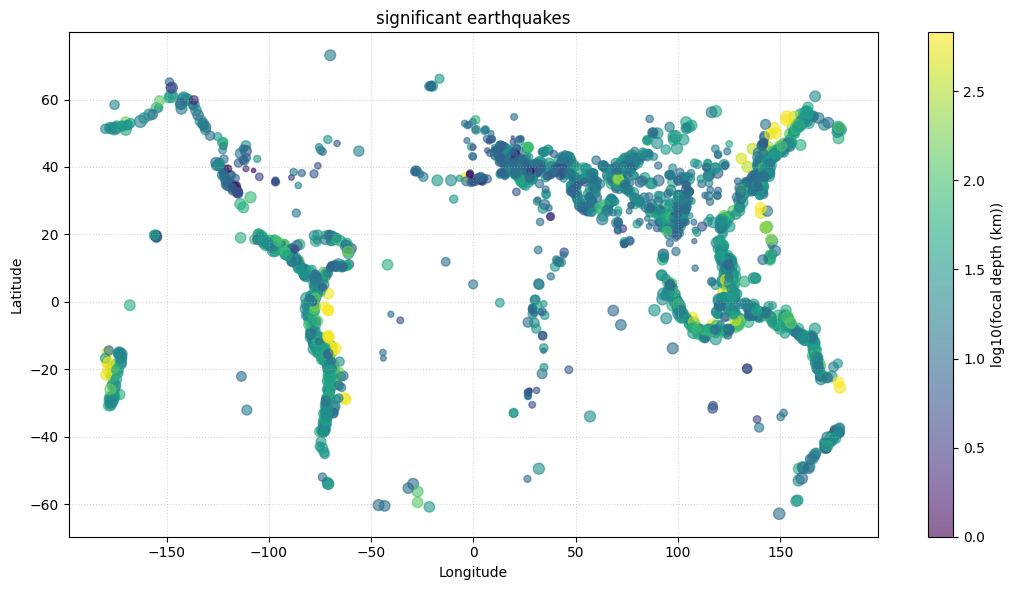

In [ ]:
# =====================================================================
# EXERCICE 21 : Séismes historiques majeurs (version complétée)
# =====================================================================
# OBJECTIF : Tracer un scatter plot de la longitude vs latitude,
# coloré par log10(profondeur) et dimensionné par magnitude ** 2.
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
import pooch

# Cellule fournie pour le téléchargement
path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/signif.txt.tsv",
    known_hash="sha256:f27e00d335f64ffaf437e74a8efb54f9154d40b417ff93fefb0fd64856e6d345",
    fname="signif.txt.tsv",
    path=pooch.os_cache("mlees"),
)

# ---------------------------------------------------------------------
# ÉTAPE 1 : CHARGER LES DONNÉES
# ---------------------------------------------------------------------
raw_data = np.genfromtxt(path, delimiter="\t", skip_header=1)

# Extraction des colonnes par leurs indices respectifs
depth = raw_data[:, 8]
mag = raw_data[:, 9]
latitude = raw_data[:, 20]
longitude = raw_data[:, 21]

# ---------------------------------------------------------------------
# ÉTAPE 2 : FILTRER / NETTOYER
# ---------------------------------------------------------------------
mask = (depth > 0) & (mag > 0) & (~np.isnan(latitude)) & (~np.isnan(longitude))

clean_depth = depth[mask]
clean_mag = mag[mask]
clean_lat = latitude[mask]
clean_lon = longitude[mask]

# ---------------------------------------------------------------------
# ÉTAPE 3 & 4 : TRACÉ & HABILLAGE
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

# Dessin du scatter plot avec la taille s et la couleur c
sc = ax.scatter(
    x=clean_lon,
    y=clean_lat,
    s=clean_mag ** 2,
    c=np.log10(clean_depth),
    cmap="viridis",
    alpha=0.6
)

# Habillage final (corrigé sans espace au début)
fig.colorbar(sc, ax=ax, label="log10(focal depth (km))")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("significant earthquakes")
ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# ÉTAPE 5 : COMMENTAIRE GÉOLOGIQUE
# ---------------------------------------------------------------------
# Les points dessinent les limites des plaques tectoniques (plate boundaries).

## Exercise 22: Antarctic sea ice, summer against winter

Two real snapshots of Antarctic sea ice concentration from NOAA/NSIDC are cached below, as
`path_winter` (1 August 2017) and `path_summer` (31 December 2017). Each holds
`seaice_conc_cdr`, the ice concentration as a fraction from 0 to 1, on a south polar
stereographic grid — its coordinates are 2D `latitude`/`longitude` arrays rather than simple 1D
dimensions, so xarray's own `.plot()` will not label it cleanly.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-seaice.png" alt="Two south polar stereographic maps of Antarctic sea ice concentration, one in austral winter with a wide ice ring and one in austral summer with much less ice" width="100%">

<em>The figure to replicate: the same field on the same projection at two dates, with the land drawn
in grey beneath the ice and one colorbar shared by both panels.</em>


Rebuild it, and say which date shows more ice.

In [23]:
# Pre-supplied: download the data files and cache them locally.
import pooch

path_winter = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/seaice_conc_daily_sh_f17_20170801_v03r01.nc",
    known_hash="sha256:1ff50bca1e6249a9b2fcd9d9466e31bdb5be650243f99c7319ab2ce625b87ce7",
    fname="seaice_conc_daily_sh_f17_20170801_v03r01.nc",
    path=pooch.os_cache("mlees"),
)
path_summer = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/seaice_conc_daily_sh_f17_20171231_v03r01.nc",
    known_hash="sha256:309418969ad09f42b8104589bcb86de4ed353a5742fef9385baec174c7d55e66",
    fname="seaice_conc_daily_sh_f17_20171231_v03r01.nc",
    path=pooch.os_cache("mlees"),
)

In [28]:
# Your solution here

# =====================================================================
# EXERCICE 22 : glace de mer antarctique, été contre hiver (version à trous)
# =====================================================================
#
# OBJECTIF GLOBAL (ce que demande l'énoncé) :
#   À partir de deux instantanés réels NOAA/NSIDC de la concentration de glace
#   de mer en Antarctique (1er août 2017 et 31 décembre 2017), reproduire une
#   figure à deux panneaux :
#     - deux cartes sur la MÊME projection (stéréographique polaire sud) ;
#     - la terre en gris, dessinée SOUS la glace ;
#     - une SEULE colorbar partagée par les deux panneaux ;
#   puis dire en commentaire quelle date montre le plus de glace.
#
# Schéma général : charger -> masquer les valeurs invalides -> créer deux axes
#                  cartopy -> tracer chaque panneau -> une colorbar commune.
# Idées du chapitre :
#   - les coordonnées latitude/longitude sont ici 2D (une paire par case), donc le
#     .plot() d'xarray ne les étiquette pas proprement : on utilise pcolormesh
#     de matplotlib, en lui passant ces deux tableaux 2D ;
#   - `transform=ccrs.PlateCarree()` dit à cartopy que les coordonnées données
#     sont de simples lon/lat, pas déjà projetées (sinon la glace est mal placée,
#     sans aucune erreur : voir l'exercice 17).
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pooch

#
# CELLULE FOURNIE PAR L'ÉNONCÉ (ne pas modifier)
# Ce que ça fait : télécharge les deux fichiers netCDF et les garde en cache.
# path_winter : 1er août 2017 (hiver austral) ; path_summer : 31 décembre 2017 (été austral).
#
path_winter = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/seaice_conc_daily_sh_f17_20170801_v03r01.nc",
    known_hash="sha256:1ff50bca1e6249a9b2fcd9d9466e31bdb5be650243f99c7319ab2ce625b87ce7",
    fname="seaice_conc_daily_sh_f17_20170801_v03r01.nc",
    path=pooch.os_cache("mlees"),
)
path_summer = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/seaice_conc_daily_sh_f17_20171231_v03r01.nc",
    known_hash="sha256:309418969ad09f42b8104589bcb86de4ed353a5742fef9385baec174c7d55e66",
    fname="seaice_conc_daily_sh_f17_20171231_v03r01.nc",
    path=pooch.os_cache("mlees"),
)

#
# ÉTAPE 1 : OUVRIR LES DEUX FICHIERS ET CHOISIR L'UNIQUE PAS DE TEMPS
# Énoncé : "open each file with xr.open_dataset and select the single time step
#           with .isel(time=0)".

#
ds_winter = xr.open_dataset(path_winter).isel(time=0)      # TODO : quelle fonction ? quel chemin ? quel indice ?
ds_summer = xr.open_dataset(path_summer).isel(time=0)      # TODO
print(ds_winter)     # TODO : repère le nom des dimensions, de la variable et des coordonnées 2D

#
# ÉTAPE 2 : MASQUER LES VALEURS INVALIDES
# Énoncé : "The valid concentration range is 0-1; a few cells carry flag values
#           above 1 (land, coastal, missing) -- mask them out first with
#           da.where(da <= 1)".
#
conc_winter = ds_winter[___]                # TODO : nom de la variable de concentration
conc_summer = ds_summer[___]                # TODO
print(float(conc_winter.max()))             # TODO : avant masque, le maximum est-il > 1 ?

winter = conc_winter.where(conc_winter ___ ___)   # TODO : quelle comparaison, quelle valeur ?
summer = conc_summer.where(conc_summer ___ ___)   # TODO
print(float(winter.max()))                  # TODO : après masque, le maximum doit être <= 1

#
# ÉTAPE 3 : CRÉER LA FIGURE AVEC DEUX AXES CARTOPY
# Énoncé : "build a figure with two ccrs.SouthPolarStereo() axes".
# Hint de l'énoncé : plt.subplots(1, 2, subplot_kw={"projection": ccrs.SouthPolarStereo()})
#
fig, axes = plt.subplots(1, 2, figsize=(___, ___),
                         subplot_kw={"projection": ccrs.___()})   # TODO : taille ; projection polaire sud
print(axes.shape)                           # TODO : attendu (2,)

#
# ÉTAPE 4 : TRACER LES DEUX PANNEAUX
# Énoncé : "the same field on the same projection at two dates, with the land
#           drawn in grey beneath the ice".
#
panels = [(axes[0], ds_winter, winter, "1 August 2017"),
          (axes[1], ds_summer, summer, "31 December 2017")]

for ax, ds_i, field, label in panels:
    ax.set_extent([___, ___, ___, ___], ccrs.PlateCarree())             # TODO : lon min/max, lat min/max
    ax.add_feature(cfeature.LAND, facecolor=___, zorder=___)            # TODO : couleur grise ; zorder sous la glace
    pcm = ax.pcolormesh(ds_i[___], ds_i[___], field,                    # TODO : coordonnées 2D (longitude, latitude)
                        vmin=___, vmax=___,                             # TODO : bornes communes de l'échelle
                        transform=ccrs.___())                           # TODO : quelle projection pour les coordonnées ?
    ax.gridlines()
    ax.set_title(label)

#
# ÉTAPE 5 : UNE SEULE COLORBAR POUR LES DEUX PANNEAUX
# Énoncé : "one colorbar shared by both panels".
#
fig.colorbar(pcm, ax=___, label=___)        # TODO : quel argument pour les axes ? quel label ?

# ÉTAPE 6 : AFFICHER
# Énoncé : "Rebuild it" (la figure).
plt.___()                                    # TODO

# ÉTAPE 7 : LE COMMENTAIRE DEMANDÉ
# Énoncé : "say which date shows more ice."
# Ce que fait cette étape : tu interprètes la figure, il n'y a pas de code.
# Pistes pour ta réponse (à reformuler avec tes mots) :
#   - sur quelle carte l'anneau coloré autour du continent est-il le plus large ?
#   - août et décembre : quelle saison est-ce dans l'hémisphère sud,
#     et pourquoi la glace s'étend-elle plus à une saison qu'à l'autre ?
# TODO : écris ici 1-2 phrases.




<xarray.Dataset> Size: 5MB
Dimensions:                         (ygrid: 332, xgrid: 316)
Coordinates:
  * ygrid                           (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                           (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    time                            datetime64[ns] 8B 2017-08-01T12:00:00
    latitude                        (ygrid, xgrid) float64 839kB ...
    longitude                       (ygrid, xgrid) float64 839kB ...
Data variables:
    projection                      |S1 1B ...
    seaice_conc_cdr                 (ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr        (ygrid, xgrid) float32 420kB ...
    melt_onset_day_seaice_conc_cdr  (ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr           (ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc      (ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc          (ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc          (ygrid, xgri

In [26]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 45.0 MB/s eta 0:00:00


In [24]:
# HINT ETAPE 1:
# Ce que fait cette étape :
#   - open_dataset lit un fichier netCDF et renvoie un Dataset (comme à l'exercice 14) ;
#   - chaque fichier ne contient qu'une date, mais la dimension "time" existe
#     quand même (de taille 1) : .isel(time=0) la supprime pour garder un
#     tableau 2D (par position, comme à l'exercice 14).
# Résultat : un Dataset 2D par saison, avec seaice_conc_cdr et les coordonnées
#   2D latitude et longitude.

# HINT ETAPE 2:
# Ce que fait cette étape :
#   - seaice_conc_cdr est une fraction entre 0 et 1, mais certaines cases portent
#     des codes spéciaux supérieurs à 1 (terre, côte, manquant) ;
#   - .where(condition) garde les valeurs où la condition est vraie et met NaN
#     partout ailleurs ;
#   - sans ce masque, ces codes écraseraient l'échelle de couleurs ;
#   - les cases mises à NaN ne sont pas dessinées : c'est ce qui laisse apparaître
#     la terre grise dessinée en dessous (étape 4).

# HINT ETAPE 3:
# Ce que fait cette étape :
#   - subplot_kw passe l'argument projection à CHAQUE axe créé : les deux
#     panneaux sont donc des cartes en projection polaire sud ;
#   - axes est un tableau de forme (2,) : axes[0] à gauche, axes[1] à droite.

# HINT ETAPE 4 :
# Hints de l'énoncé :
#   - ax.set_extent([-180, 180, -90, -55], ccrs.PlateCarree()) : cadre l'océan Austral ;
#   - ax.pcolormesh(ds["longitude"], ds["latitude"], masked, transform=ccrs.PlateCarree()) ;
#   - vmin=0 et vmax=1 dans les DEUX pcolormesh : une couleur a la même signification
#     dans les deux panneaux, donc une seule colorbar suffira ;
#   - cfeature.LAND sous les données, et des gridlines.
# Ce que fait cette étape :
#   - on répète les mêmes opérations pour l'hiver (panneau 0) et l'été (panneau 1) ;
#   - set_extent coupe la carte à 55°S et au sud (sinon on voit tout l'hémisphère) ;
#   - pcolormesh reçoit les coordonnées 2D et le champ masqué, avec transform ;
#   - la terre grise doit passer SOUS la glace : donne à add_feature un zorder plus
#     petit que celui de la glace (le zorder de pcolormesh est 1 par défaut) ;
#   - gridlines trace le quadrillage.

# HINT ETAPE 5 :
# Hint de l'énoncé : fig.colorbar(pcm, ax=axes, label=...) prend le TABLEAU de
#                    tous les axes et dessine une seule colorbar pour les deux.
# Ce que fait cette étape :
#   - pcm (le dernier tracé) sert de modèle pour les couleurs ; comme vmin/vmax
#     sont identiques dans les deux panneaux, la colorbar est valable pour les deux ;
#   - ax=axes (au pluriel, le tableau entier) fait de la place à côté des deux cartes ;
#   - le label doit nommer la grandeur : concentration de glace (fraction, de 0 à 1).


# HINT ETAPE 6 :
# Ce que fait cette étape : show affiche la figure.
# Remarque : tight_layout n'est pas utilisé ici, car fig.colorbar(ax=axes) a déjà
#   réservé la place de la colorbar ; il pourrait la déplacer.

## Exercise 23: The 2014 earthquakes over North America

The file cached below is the real USGS earthquake catalog for 2014 — one row per event
worldwide, with latitude, longitude, depth and magnitude in columns 1 to 4. The target figure
keeps the whole catalog and lets the map extent do the selecting, so what you see is a window
onto a global dataset rather than one cropped to North America in advance.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-earthquakes-map.png" alt="A Robinson-projection map of North America with state boundaries, lakes and rivers, and earthquake locations coloured by depth" width="90%">

<em>The figure to replicate: magnitude 4 and above, on a Robinson projection cropped to North and
Central America, over land, ocean, lake, river and state-boundary features.</em>


Rebuild it.

In [ ]:
# Pre-supplied: download the data file and cache it locally.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/usgs_earthquakes_2014.csv",
    known_hash="sha256:84d455fb96dc8f782fba4b5fbe56cb8970cab678f07c766fcba1b1c4674de1b1",
    fname="usgs_earthquakes_2014.csv",
    path=pooch.os_cache("mlees"),
)

In [ ]:
# Your solution here

# =====================================================================
# EXERCICE 23 : les séismes de 2014 sur l'Amérique du Nord (version à trous)
# =====================================================================
#
# OBJECTIF GLOBAL (ce que demande l'énoncé) :
#   À partir du vrai catalogue USGS des séismes de 2014 (un séisme par ligne,
#   pour le monde entier), reproduire une carte :
#     - projection Robinson, recadrée sur l'Amérique du Nord et centrale ;
#     - fonds de carte : terre, océan, lacs, rivières, frontières des États ;
#     - un point par séisme de magnitude >= 4, COLORÉ par le logarithme de la
#       profondeur et DIMENSIONNÉ par la magnitude ;
#     - quadrillage, colorbar avec label, titre.
#   Remarque de l'énoncé : on garde TOUT le catalogue mondial, et c'est l'étendue
#   de la carte (set_extent) qui fait la sélection géographique : on ne découpe
#   pas les données à l'avance.
#
# Schéma général : charger -> filtrer -> créer l'axe cartopy -> fonds de carte
#                  -> scatter -> habillage.
# Cet exercice reprend le scatter de l'exercice 21 (couleur = log10 de la
# profondeur, taille = magnitude²) et y ajoute la carte cartopy de l'exercice 22.
# Piège central : `transform=ccrs.PlateCarree()` dit à cartopy que les
# coordonnées données sont de simples lon/lat (voir l'exercice 17).
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pooch

# CELLULE FOURNIE PAR L'ÉNONCÉ (ne pas modifier)
# Ce que ça fait : télécharge le catalogue CSV et le garde en cache local.
# `path` contient ensuite le chemin du fichier.

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/usgs_earthquakes_2014.csv",
    known_hash="sha256:84d455fb96dc8f782fba4b5fbe56cb8970cab678f07c766fcba1b1c4674de1b1",
    fname="usgs_earthquakes_2014.csv",
    path=pooch.os_cache("mlees"),
)

# ÉTAPE 1 : CHARGER LES QUATRE COLONNES NUMÉRIQUES
# Énoncé : "latitude, longitude, depth and magnitude in columns 1 to 4".

data = np.genfromtxt(path, delimiter=___, skip_header=___, usecols=___)   # TODO : valeurs de l'énoncé
print(data.shape)       # TODO : attendu (n_séismes, 4)
print(data[:3])         # TODO : latitude entre -90 et 90 ? longitude entre -180 et 180 ? magnitude ~ 4-7 ?

# ÉTAPE 2 : EXTRAIRE LES QUATRE COLONNES SOUS DES NOMS LISIBLES


latitude = data[:, ___]      # TODO : quel indice de colonne ?
longitude = data[:, ___]     # TODO
depth_km = data[:, ___]      # TODO
mag = data[:, ___]           # TODO

# ÉTAPE 3 : FILTRER (magnitude >= 4 ET profondeur > 0)
# Énoncé : "keep mag >= 4 and depth_km > 0 (a few events are recorded at exactly
#           0 km, which np.log10 cannot take)".

keep = (mag ___ ___) & (depth_km ___ ___)    # TODO : deux conditions de l'énoncé
latitude = latitude[keep]
longitude = longitude[keep]
depth_km = depth_km[keep]
mag = mag[keep]
print(keep.sum(), "séismes conservés sur", keep.size)   # TODO : le nombre conservé est-il bien plus petit ?

# ÉTAPE 4 : CRÉER L'AXE EN PROJECTION ROBINSON ET LE RECADRER
# Énoncé : "a Robinson-projection map ... cropped to North and Central America".


fig, ax = plt.subplots(figsize=(10, 7),
                       subplot_kw={"projection": ccrs.___()})      # TODO : quelle projection ?
ax.set_extent([___, ___, ___, ___], ccrs.___())                    # TODO : bornes de l'énoncé ; système de coordonnées

#
# ÉTAPE 5 : LES FONDS DE CARTE
# Énoncé : "land, ocean, lake, river and state-boundary features".


ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.STATES, edgecolor=___, linewidth=___)      # TODO : gris ; trait fin

#
# ÉTAPE 6 : LE NUAGE DE POINTS (scatter)
# Énoncé : "earthquake locations coloured by depth".
#
sc = ax.scatter(___, ___, transform=ccrs.___(),            # TODO : x, y ; système des coordonnées
                c=np.___(___), s=___, zorder=3)             # TODO : log10 de quoi ? aire en fonction de quoi ?

#
# ÉTAPE 7 : HABILLAGE ET AFFICHAGE
# Énoncé : "finish with ax.gridlines, a labelled colorbar, and a title".


ax.gridlines()
fig.colorbar(sc, ax=ax, label=___, shrink=0.7)             # TODO : grandeur et unité
ax.set_title(___)                                          # TODO
plt.show()



In [ ]:
# HINT ETAPE 1
# Hint de l'énoncé : np.genfromtxt(path, delimiter=",", skip_header=1,
#                    usecols=(1, 2, 3, 4))
# Ce que fait cette étape :
#   - delimiter="," : colonnes séparées par des virgules ;
#   - skip_header=1 : saute la ligne de titres ;
#   - usecols : ne lit QUE les colonnes 1 à 4 ; les colonnes de texte (heure, lieu...)
#     mélangées aux nombres sont ignorées. La colonne 0 est donc sautée ;
#   - le résultat est un tableau 2D : une ligne par séisme, quatre colonnes
#     dans l'ordre latitude, longitude, profondeur (km), magnitude.

# HINT ETAPE 2
# Ce que fait cette étape :
#   - data[:, k] prend la colonne k (toutes les lignes) ;
#   - on donne un nom à chaque colonne pour que la suite soit lisible
#     (comme à l'exercice 21, où on faisait arr[:, 8]).


# HINT ETAPE 3
# Ce que fait cette étape :
#   - un masque est un tableau de True/False, un par séisme ;
#   - & combine deux masques élément par élément ("et") ; chaque comparaison doit
#     être entre parenthèses, sinon Python lit mal l'expression ;
#   - np.log10(0) donne -inf : d'où l'exclusion des profondeurs nulles ;
#   - on applique le MÊME masque aux quatre tableaux pour garder les lignes alignées.
#   - on NE filtre PAS sur la région : set_extent s'en charge à l'étape 4.


# HINT ETAPE 4
# Hints de l'énoncé :
#   - fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Robinson()})
#   - ax.set_extent([-140, -60, 12, 70], ccrs.PlateCarree())
# Ce que fait cette étape :
#   - subplot_kw={"projection": ...} fait de l'axe une carte cartopy ;
#   - set_extent prend [lon min, lon max, lat min, lat max] : c'est la "fenêtre"
#     sur le catalogue mondial ; les séismes hors fenêtre ne sont simplement pas
#     visibles ;
#   - le deuxième argument de set_extent précise dans QUEL système sont exprimées
#     ces bornes (ici des lon/lat simples).


# HINT ETAPE 5
# Hint de l'énoncé : add_feature accepte edgecolor, facecolor et linewidth ;
#                    STATES se lit mieux en gris et en trait fin.
# Ce que fait cette étape :
#   - add_feature ajoute une couche de fond de carte ;
#   - on garde le style par défaut pour la terre, l'océan, les lacs et les rivières ;
#   - les frontières des États sont des traits : on règle leur couleur et leur épaisseur
#     pour qu'ils restent discrets.

# HINT ETAPE 6
# Hint de l'énoncé : ax.scatter(longitude, latitude, transform=ccrs.PlateCarree(),
#                    c=np.log10(depth_km), s=mag ** 2)
# Ce que fait cette étape :
#   - scatter place un point par séisme : x = longitude, y = latitude
#     (dans cet ordre : x d'abord) ;
#   - c = np.log10(profondeur) colore chaque point par l'ordre de grandeur de la
#     profondeur : sans le log, les séismes superficiels se ressembleraient tous ;
#   - s = mag ** 2 : l'AIRE du point croît comme le carré de la magnitude ;
#   - transform dit à cartopy que (longitude, latitude) sont de simples lon/lat,
#     pas des coordonnées déjà projetées. Sans lui, les points sont mal placés
#     et aucune erreur n'apparaît ;
#   - zorder=3 dessine les points AU-DESSUS des fonds de carte (sinon la terre,
#     l'océan ou les États peuvent les recouvrir) ;
#   - on garde le résultat dans `sc` : la colorbar en a besoin.


# HINT ETAPE 7
# Ce que fait cette étape :
#   - gridlines trace le quadrillage méridiens/parallèles ;
#   - fig.colorbar(sc, ax=ax, label=...) traduit les couleurs en valeurs :
#     le label doit dire que c'est le log10 de la profondeur, en km ;
#   - le titre dit quoi, où et quand (n'oublie pas le seuil de magnitude).

# ---------------------------------------------------------------------
# AUTO-VÉRIFICATION (pas de commentaire demandé ici, mais regarde bien)
#   - les points se concentrent-ils le long de certaines lignes (côtes, arcs) ?
#     Compare avec ce que tu as vu à l'exercice 21 ;
#   - les gros points correspondent-ils aux grandes magnitudes ?
#   - que se passerait-il sans transform=ccrs.PlateCarree() ? (essaie de le retirer
#     une fois, puis remets-le : c'est l'exercice 17).
# ---------------------------------------------------------------------